In [70]:
%matplotlib inline

# Introduction to Deep Learning with Keras and TensorFlow

**Daniel Moser (UT Southwestern Medical Center)**

**Resources: [Xavier Snelgrove](https://github.com/wxs/keras-mnist-tutorial), [Yash Katariya](https://github.com/yashk2810/MNIST-Keras)**

To help you understand the fundamentals of deep learning, this demo will walk through the basic steps of building two toy models for classifying handwritten numbers with accuracies surpassing 95%. The first model will be a basic fully-connected neural network, and the second model will be a deeper network that introduces the concepts of convolution and pooling.

## Prerequisite Python Modules

First, some software needs to be loaded into the Python environment.

In [71]:
import numpy as np                   # advanced math library
import matplotlib.pyplot as plt      # MATLAB like plotting routines
import random                        # for generating random numbers

from keras.datasets import mnist     # MNIST dataset is included in Keras
from keras.models import Sequential  # Model type to be used

from keras.layers import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.utils import to_categorical # Corrected import for to_categorical

## Loading Training Data

The MNIST dataset is conveniently bundled within Keras, and we can easily analyze some of its features in Python.

In [91]:
# The MNIST data is split between 60,000 28 x 28 pixel training images and 10,000 28 x 28 pixel images
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Convert labels: 1 = even, 0 = odd
# y_train = (y_train % 2 == 0).astype(int)
# y_test  = (y_test % 2 == 0).astype(int)

print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


‎

___________

‎

**a. Defining the training sizes**

In [92]:
train_sizes = [1000, 5000, 10000, 20000, 40000, 60000]

fc_accuracies = []
cnn_accuracies = []

print("Train sizes:", train_sizes)

Train sizes: [1000, 5000, 10000, 20000, 40000, 60000]


‎

______________________

‎

In [97]:
# Step 2: Train/evaluate Fully Connected model for each training size

# Redefine dataset:
# X_train_raw: Original training images
# y_train_raw: Original labels
# X_test_raw: orignal test images
# y_test_raw: original test labels
# : This ensure a clean starting point. Tuple unpacking.
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()


# Preprocess for FC: flatten + normalize
# 28x28 flatten to a singular vector of length 784
# Training and testing data must undergo identicla preprocessing
X_train_fc = X_train_raw.reshape(60000, 784).astype("float32") / 255.0
X_test_fc  = X_test_raw.reshape(10000, 784).astype("float32") / 255.0

# One-hot labels for 10-class digit prediction
# Labels now appaer like this: [0,0,0,0,0,1,0,0,0,0] = digit 5
# where softmax outputs 10 probabilties, one per class
nb_classes = 10

# Function call: labels are a 1D array of integers, num_classes are total number of possible classes
Y_train_10 = to_categorical(y_train_raw, nb_classes)
Y_test_10  = to_categorical(y_test_raw, nb_classes)


# Each layer takes the output of the previous layer and uses it as input for the next.
# Dense: Dense = fully connected.
# relu: Nonlinearity. If there are negative numbers, they will just be 0 while positive values
#       remain the same.
# sofmax: converts vector into probablites that sum to 1
# dropout: Randonly sets 20% of neurons to zero. This forces the network to not rely on
#          a single neuron. Only active during training
# More dense layers: adds more depth which allows for hierarchical representations and more
#                    complex decision boundaries
# Dense(10): Output layer. Produces 10 raw scores and softmax converts them into probablites.
def build_fc_model():
    model = Sequential()
    model.add(Dense(512, input_shape=(784,)))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))
    model.add(Dense(10))
    model.add(Activation('softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

fc_accuracies = []

# n for in train_size: calls back to defines list earlier.
# model_fc builds a new moedel to isolate the new training size
# _ ignores the loss and just stores the accuracy
for n in train_sizes:
    model_fc = build_fc_model()

    model_fc.fit(X_train_fc[:n],
                 Y_train_10[:n],
                 batch_size=128,
                 epochs=5,
                 verbose=0
                 )

    _, acc = model_fc.evaluate(X_test_fc, Y_test_10, verbose=0)
    fc_accuracies.append(acc)
    print(f"FC | n={n:>5} | test_acc={acc:.4f}")

print("FC accuracies:", fc_accuracies)


FC | n= 1000 | test_acc=0.8828
FC | n= 5000 | test_acc=0.9372
FC | n=10000 | test_acc=0.9476
FC | n=20000 | test_acc=0.9697
FC | n=40000 | test_acc=0.9781
FC | n=60000 | test_acc=0.9825
FC accuracies: [0.8827999830245972, 0.9372000098228455, 0.9476000070571899, 0.9696999788284302, 0.9781000018119812, 0.9825000166893005]


‎

_________________

‎

In [99]:
from keras.layers import Conv2D, MaxPooling2D, Flatten

# Reload MNIST for 10-class digit prediction (0-9)
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Preprocess for CNN: keep 28x28 and add channel dimension + normalize
X_train_cnn = X_train_raw.reshape(60000, 28, 28, 1).astype("float32") / 255.0
X_test_cnn  = X_test_raw.reshape(10000, 28, 28, 1).astype("float32") / 255.0

# One-hot labels
nb_classes = 10
Y_train_10 = to_categorical(y_train_raw, nb_classes)
Y_test_10  = to_categorical(y_test_raw, nb_classes)

def build_cnn_model():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

cnn_accuracies = []

for n in train_sizes:
    model_cnn = build_cnn_model()
    model_cnn.fit(X_train_cnn[:n], Y_train_10[:n], batch_size=128, epochs=5, verbose=0)
    _, acc = model_cnn.evaluate(X_test_cnn, Y_test_10, verbose=0)
    cnn_accuracies.append(acc)
    print(f"CNN | n={n:>5} | test_acc={acc:.4f}")

print("CNN accuracies:", cnn_accuracies)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN | n= 1000 | test_acc=0.8797
CNN | n= 5000 | test_acc=0.9602
CNN | n=10000 | test_acc=0.9729
CNN | n=20000 | test_acc=0.9811
CNN | n=40000 | test_acc=0.9871
CNN | n=60000 | test_acc=0.9886
CNN accuracies: [0.8797000050544739, 0.9602000117301941, 0.9728999733924866, 0.9811000227928162, 0.9871000051498413, 0.9886000156402588]


‎

_______________

‎

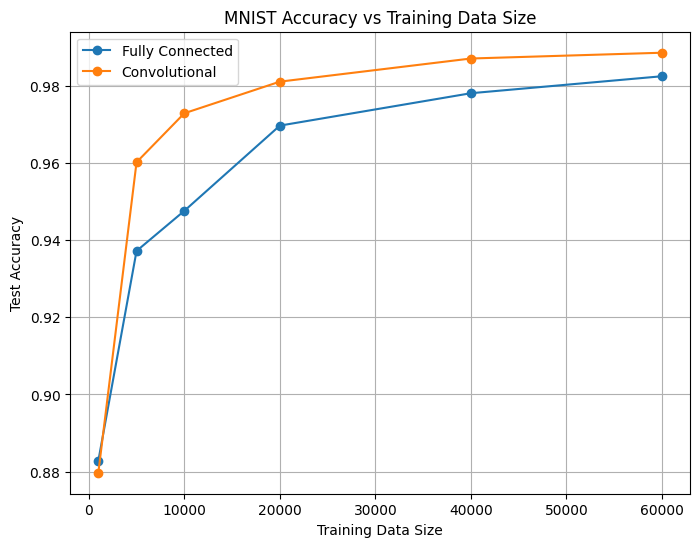

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(train_sizes, fc_accuracies, marker='o', label='Fully Connected')
plt.plot(train_sizes[:len(cnn_accuracies)], cnn_accuracies, marker='o', label='Convolutional')

plt.xlabel('Training Data Size')
plt.ylabel('Test Accuracy')
plt.title('MNIST Accuracy vs Training Data Size')
plt.legend()
plt.grid(True)

plt.show()
